## Visual Autoencoder pretraining

In [ ]:
!pip install torchinfo
!pip install clip
!pip install evaluate
!pip install diffusers
!pip install lpips

In [2]:
# @title Importing the necessary libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import CLIPProcessor, CLIPModel, RobertaModel, RobertaTokenizer
import evaluate
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import tqdm
from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as FT
import math
from transformers import BertTokenizer
import gc

import textwrap

# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [3]:

base=64
time_dim=256
clip_layers=(4, 8, 12)
clip_proj=128
use_clip=True
batch_size = 16
dropout = 0.1
device = device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now we load dataset from HuggingFace:

In [6]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoningAdversarialDPO")

Generating train split:   0%|          | 0/10656 [00:00<?, ? examples/s]

## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [7]:
# @title CoT improvements toggles (added)
"""
Configuration flags to control which Chain-of-Thought (CoT) mechanisms are used during training:
- `USE_FRAME_AWARE_GROUNDING`: Aligns ROI embeddings with the text embedding of the specific frame (vs global).
- `USE_CONTRASTIVE_ROI`: Enables InfoNCE loss to contrast positive ROI-text pairs against negatives.
- `USE_ENTITY_POOLING`: Enforces consistency of embeddings for the same entity within a batch.
- `USE_COT_TEXT`: Appends CoT reasoning text to the input frame description.
"""

# Turn these on/off to control the 4 optional improvements.
USE_FRAME_AWARE_GROUNDING = True      # Option 2: align ROI to matching frame text embedding (instead of always frame 0)
USE_CONTRASTIVE_ROI = True            # Option 1: InfoNCE-style contrastive grounding using batch negatives
USE_ENTITY_POOLING = True             # Option 3: entity-specific pooling/consistency across batch by entity_id
USE_COT_TEXT = True                   # Option 4: concatenate CoT text snippet to the frame descriptions

# Contrastive temperature (only used if USE_CONTRASTIVE_ROI=True)
CONTRASTIVE_TAU = 0.07

## 1.3 Creating and testing our dataset objects and loaders


---



In [8]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderDataset` and its `DataLoader`.
"""
from src.utils.helper import AutoEncoderDataset
autoencoder_dataset = AutoEncoderDataset(train_dataset['train'])
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=batch_size, shuffle=True)

# **Models**


---



## The Vision models

## 3.1 Initialization and setup

In [10]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""
from src.models.visual_autoencoder import CLIPDiffusionUNet, init_weights, zero_init_output, AttentionBlock, CLIPMultiScale, GaussianDiffusion
# =========================================================
# INSTANTIATE
# =========================================================
model = CLIPDiffusionUNet(
    base=base,
    time_dim=time_dim,
    clip_layers=clip_layers,   # low / mid / high CLIP depths
    clip_proj=clip_proj,
    use_clip=use_clip,
).to(device)

model.apply(init_weights)
zero_init_output(model)       # start by predicting ~zero noise -> stable warmup

visual_autoencoder = GaussianDiffusion(model, timesteps=1000, device=device)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total:,}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Total trainable parameters: 56,836,675


## 3.2 Training loops


===== OVERFITTING ONE IMAGE =====



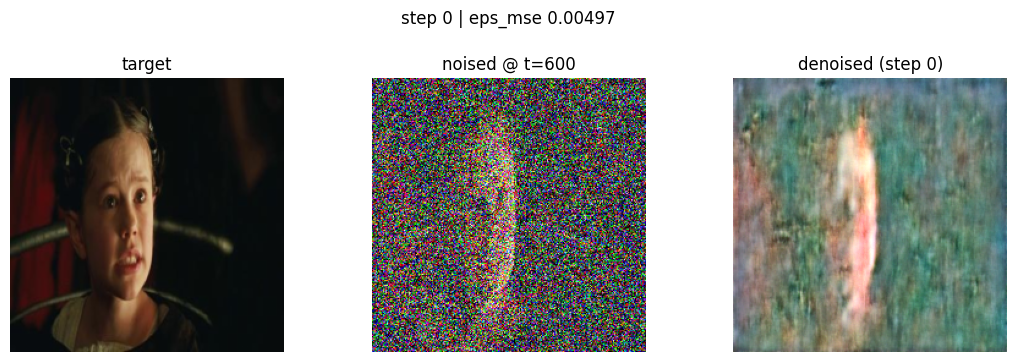

step   50 | eps_mse 0.01391


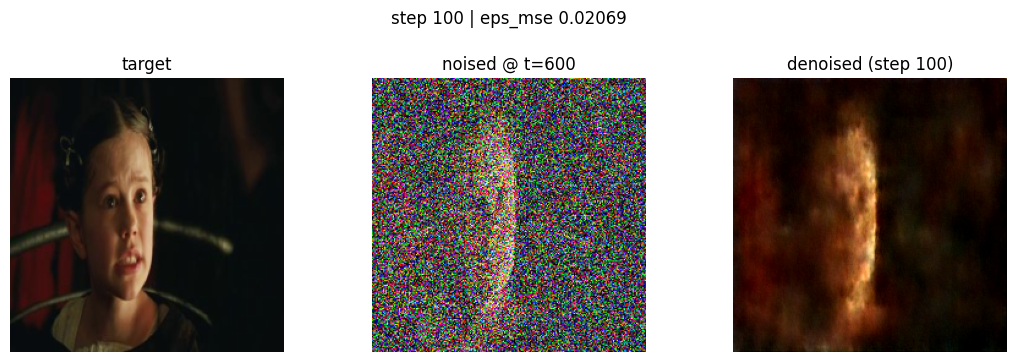

step  150 | eps_mse 0.01105


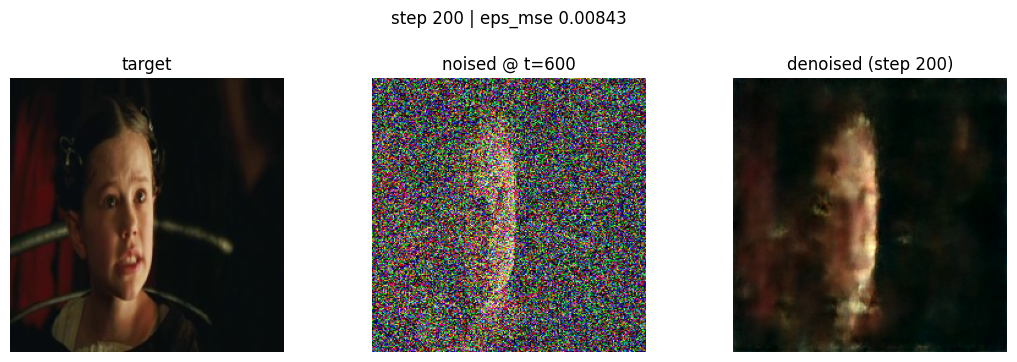

step  250 | eps_mse 0.01009


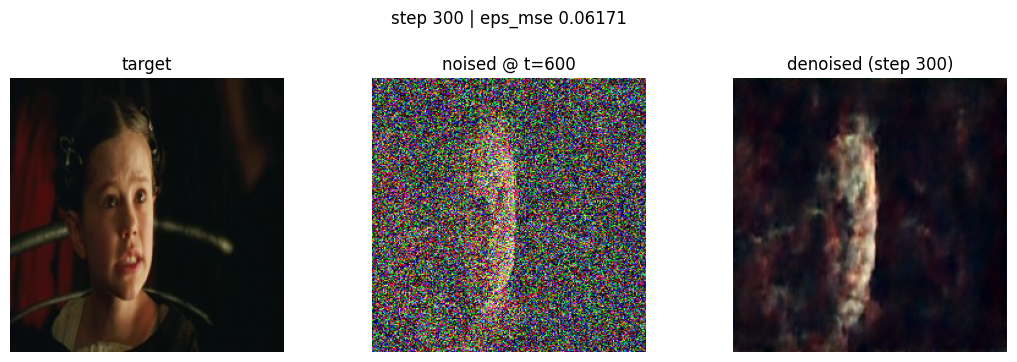

step  350 | eps_mse 0.00917


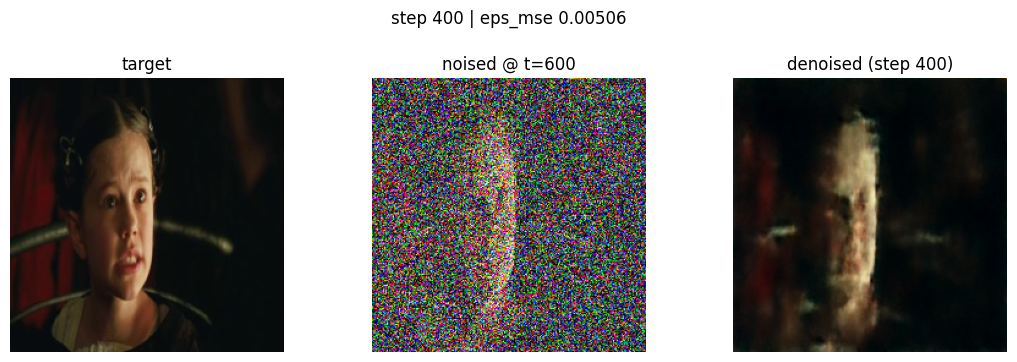

step  450 | eps_mse 0.00571


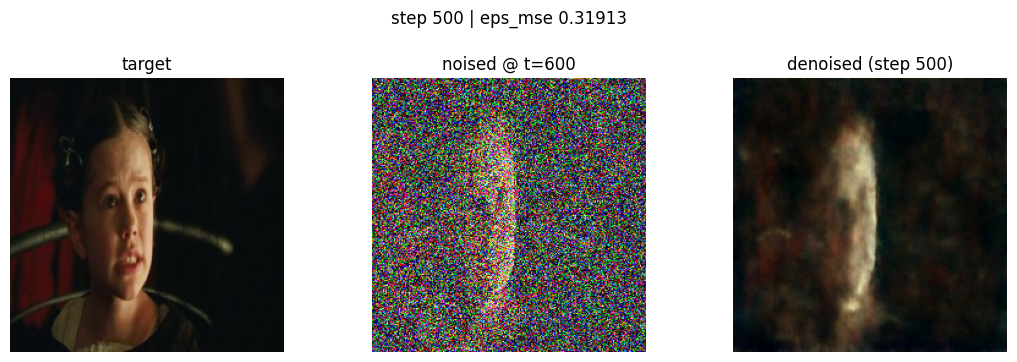

step  550 | eps_mse 0.03002


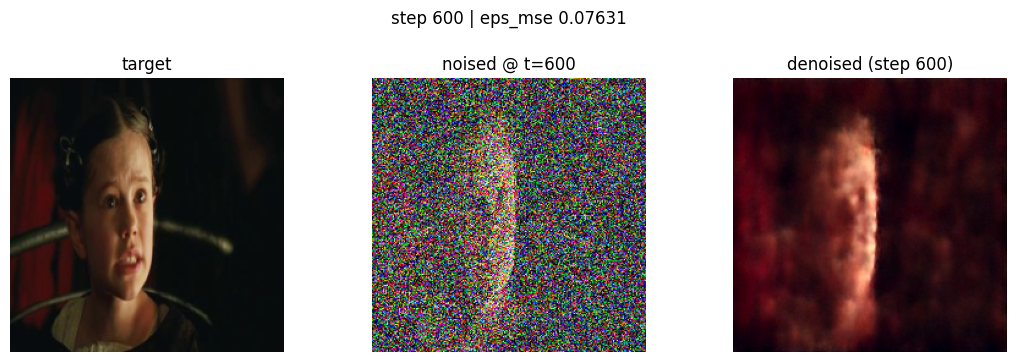

step  650 | eps_mse 0.01332


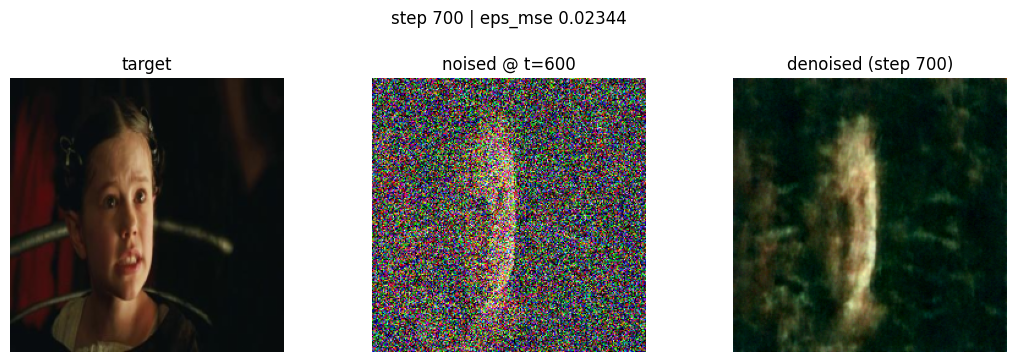

step  750 | eps_mse 0.00756


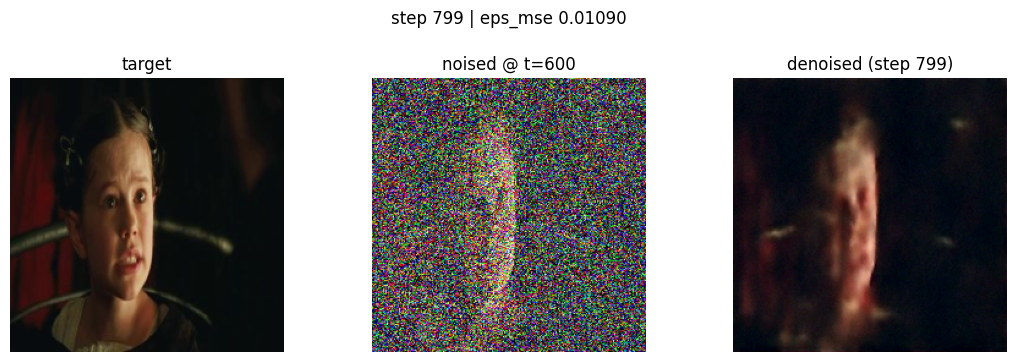

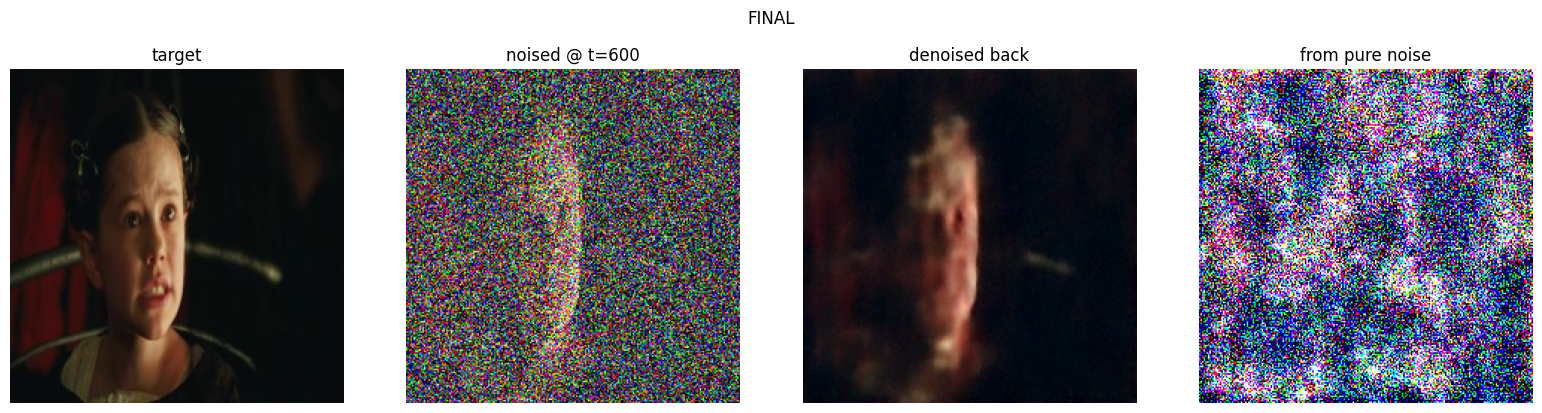

===== TEST COMPLETE =====


In [20]:
from test.visual_test import single_image_diffusion_test
single_image_diffusion_test(visual_autoencoder, autoencoder_dataloader, device)


In [ ]:
# =========================================================
# VISUAL AUTOENCODER PRETRAINING
# =========================================================

from tqdm import tqdm
from src.training.train_visual import EarlyStopping, train_diffusion
start_epoch_v = 0
checkpoint_filename_v = "visual_autoencoder.pth"

early = EarlyStopping(patience=8)
model, optimizer, history, ema = train_diffusion(
    model, visual_autoencoder, autoencoder_dataloader, device,
    n_epochs=100,
    n_eval=4,
    eval_levels=(200, 400, 600),
    eval_every=1,
    clip_lr=3e-6, unet_lr=3e-5,
    early_stopper=early,
)
